In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

## 1. Data and Returns

In [117]:
target = "^HSI"
df = yf.download(target, start = "2016-01-01")['Close']
df = df.squeeze() # Convert to Series
returns = df.pct_change().dropna()

df, returns

[*********************100%***********************]  1 of 1 completed


(Date
 2016-01-04    21327.119141
 2016-01-05    21188.720703
 2016-01-06    20980.810547
 2016-01-07    20333.339844
 2016-01-08    20453.710938
                   ...     
 2026-09-08    25317.179688
 2026-09-09    25274.960938
 2026-09-10    24954.470703
 2026-09-11    24805.630859
 2026-09-14    24902.980469
 Name: ^HSI, Length: 2631, dtype: float64,
 Date
 2016-01-05   -0.006489
 2016-01-06   -0.009812
 2016-01-07   -0.030860
 2016-01-08    0.005920
 2016-01-11   -0.027634
                 ...   
 2026-09-08   -0.003775
 2026-09-09   -0.001668
 2026-09-10   -0.012680
 2026-09-11   -0.005964
 2026-09-14    0.003924
 Name: ^HSI, Length: 2630, dtype: float64)

## 2. Return Diagnostics

In [118]:
summary = pd.DataFrame({
    "mean_daily": [returns.mean()],
    "vol_daily": [returns.std()],
    "min_daily": [returns.min()],
    "max_daily": [returns.max()],
    "n_obs": [returns.shape[0]],
})
summary

,mean_daily,vol_daily,min_daily,max_daily,n_obs
0,0.000154,0.013773,-0.132233,0.090818,2630


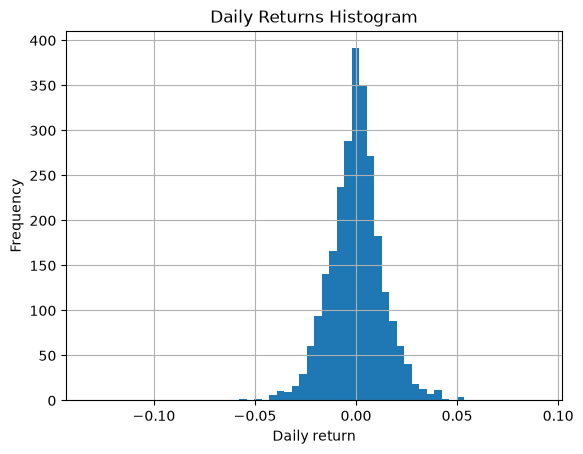

In [119]:
plt.figure()
returns.hist(bins=60)
plt.title("Daily Returns Histogram")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.show()

## 3. Historical VaR

In [120]:
CL_95 = 0.95
CL_99 = 0.99

var_hist_95 = np.percentile(returns, (1-CL_95) * 100)
var_hist_99 = np.percentile(returns, (1-CL_99) * 100)

pd.DataFrame({
    "VaR type": ["Historical", "Historical"],
    "Confidence": [CL_95, CL_99],
    "VaR (return)": [var_hist_95, var_hist_99],
})

,VaR type,Confidence,VaR (return)
0,Historical,0.95,-0.021008
1,Historical,0.99,-0.034049


## 4. Parametric VaR

In [121]:
mean = returns.mean()
std = returns.std()

var_param_95 = norm.ppf(1 - CL_95,loc=mean, scale=std)
var_param_99 = norm.ppf(1 - CL_99,loc=mean, scale=std)

pd.DataFrame({
    "VaR type": ["Parametric (Normal)", "Parametric (Normal)"],
    "Confidence": [CL_95, CL_99],
    "VaR (return)": [var_param_95, var_param_99],
})

,VaR type,Confidence,VaR (return)
0,Parametric (Normal),0.95,-0.022500
1,Parametric (Normal),0.99,-0.031886


In [122]:
compare_var = pd.DataFrame({
    "Historical VaR (return)": [var_hist_95, var_hist_99],
    "Parametric VaR (return)": [var_param_95, var_param_99],
})
compare_var

,Historical VaR (return),Parametric VaR (return)
0,-0.021008,-0.022500
1,-0.034049,-0.031886


## 5. VaR Backtesting

In [123]:
var_threshold = var_hist_95

exceptions = returns < var_threshold
exception_rate = exceptions.mean()

pd.DataFrame({
    "VaR model": ["Historical 95% (constant)"],
    "VaR threshold (return)": [var_threshold],
    "exception_rate": [exception_rate],
    "expected_rate": [1-CL_95],
    "n_exceptions": [exceptions.sum()],
    "n_total": [len(exceptions)],
})

,VaR model,VaR threshold (return),exception_rate,expected_rate,n_exceptions,n_total
0,Historical 95% (constant),-0.021008,0.05019,0.05,132,2630


In [124]:
var_threshold = var_hist_99

exceptions = returns < var_threshold
exception_rate = exceptions.mean()

pd.DataFrame({
    "VaR model": ["Historical 99% (constant)"],
    "VaR threshold (return)": [var_threshold],
    "exception_rate": [exception_rate],
    "expected_rate": [1-CL_99],
    "n_exceptions": [exceptions.sum()],
    "n_total": [len(exceptions)],
})

,VaR model,VaR threshold (return),exception_rate,expected_rate,n_exceptions,n_total
0,Historical 99% (constant),-0.034049,0.010266,0.01,27,2630


In [125]:
var_threshold = var_param_95

exceptions = returns < var_threshold
exception_rate = exceptions.mean()

pd.DataFrame({
    "VaR model": ["Parametric 95% (constant)"],
    "VaR threshold (return)": [var_threshold],
    "exception_rate": [exception_rate],
    "expected_rate": [1-CL_95],
    "n_exceptions": [exceptions.sum()],
    "n_total": [len(exceptions)],
})

,VaR model,VaR threshold (return),exception_rate,expected_rate,n_exceptions,n_total
0,Parametric 95% (constant),-0.0225,0.038023,0.05,100,2630


In [126]:
var_threshold = var_param_99

exceptions = returns < var_threshold
exception_rate = exceptions.mean()

pd.DataFrame({
    "VaR model": ["Parametric 99% (constant)"],
    "VaR threshold (return)": [var_threshold],
    "exception_rate": [exception_rate],
    "expected_rate": [1-CL_99],
    "n_exceptions": [exceptions.sum()],
    "n_total": [len(exceptions)],
})

,VaR model,VaR threshold (return),exception_rate,expected_rate,n_exceptions,n_total
0,Parametric 99% (constant),-0.031886,0.012548,0.01,33,2630


## 6. Tail Risk

In [127]:
tail_q = 0.01
tail_cutoff = returns.quantile(tail_q)
tail_returns = returns[returns <= tail_cutoff]

tail_stats = pd.DataFrame({
    "tail_quantile": [tail_q],
    "tail_cutoff (return)": [tail_cutoff],
    "avg_tail_return": [tail_returns.mean()],
    "min_tail_return": [tail_returns.min()],
    "n_tail_obs": [len(tail_returns)],
})
tail_stats

,tail_quantile,tail_cutoff (return),avg_tail_return,min_tail_return,n_tail_obs
0,0.01,-0.034049,-0.04744,-0.132233,27


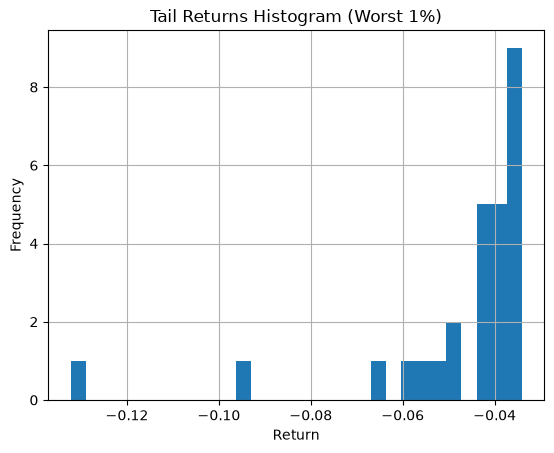

In [128]:
plt.figure()
tail_returns.hist(bins=30)
plt.title("Tail Returns Histogram (Worst 1%)")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.show()

## 7. Stress Testing

In [129]:
portfolio_value = 1_000_000

shocks = [-0.03, -0.05, -0.10]
stress_table = pd.DataFrame({
    "shock_return": shocks,
    "stress_pnl": [shock * portfolio_value for shock in shocks]
})
stress_table

,shock_return,stress_pnl
0,-0.03,-30000.0
1,-0.05,-50000.0
2,-0.10,-100000.0


In [130]:
N = 10
worst_days = returns.nsmallest(N)
hist_stress = pd.DataFrame({
    "date": worst_days.index,
    "return": worst_days.values,
    "pnl": worst_days.values * portfolio_value,
}).reset_index(drop=True)
hist_stress

,date,return,pnl
0,2025-04-07,-0.132233,-132233.471233
1,2024-10-08,-0.094070,-94069.740081
2,2022-10-24,-0.063563,-63563.139379
3,2022-03-15,-0.057168,-57167.699478
4,2020-05-22,-0.055597,-55596.665695
5,2018-02-06,-0.051164,-51164.195663
6,2022-03-14,-0.049729,-49729.463660
7,2020-03-23,-0.048627,-48626.881563
8,2020-03-09,-0.042308,-42307.834523
9,2021-07-27,-0.042222,-42221.941844


## 8. Drawdowns

In [131]:
cum = (1 + returns).cumprod()
draw = cum / cum.cummax() - 1

draw_stats = pd.DataFrame({
    "max_drawdown" : [draw.min()],
    "max_drawdown_pnl" : [draw.min() * portfolio_value],
})
draw_stats

,max_drawdown,max_drawdown_pnl
0,-0.557008,-557007.72493


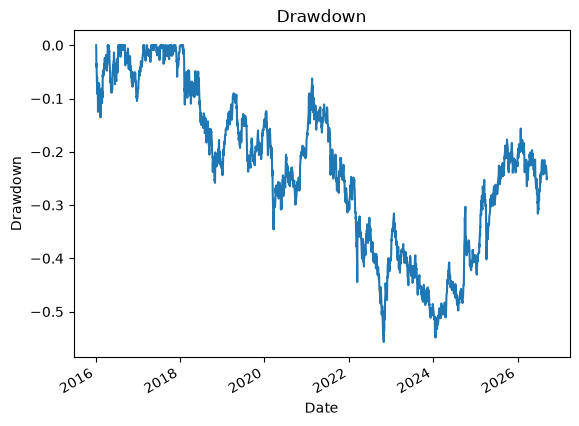

In [132]:
plt.figure()
draw.plot()
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.show()

## 9. Risk Report

In [134]:
report = pd.DataFrame({
    "Metric": [
        f"Historical VaR {int(CL_95*100)}%",
        f"Parametric VaR {int(CL_95*100)}% (Assuming Normal)",
        f"Tail Loss (worst {int(tail_q*100)}%) avg",
        "Worst Drawdown",
        "Stress PnL (-10%)",
        f"Worst {N} days avg PnL",
    ],
    "Value": [
        var_hist_95 * portfolio_value,
        var_param_95 * portfolio_value,
        tail_returns.mean() * portfolio_value,
        draw.min() * portfolio_value,
        -0.10 * portfolio_value,
        hist_stress["pnl"].mean() if len(hist_stress) > 0 else np.nan,
    ]
})
report

,Metric,Value
0,Historical VaR 95%,-21007.651329
1,Parametric VaR 95% (Assuming Normal),-22499.913652
2,Tail Loss (worst 1%) avg,-47440.430335
3,Worst Drawdown,-557007.724930
4,Stress PnL (-10%),-100000.000000
5,Worst 10 days avg PnL,-63668.103312
